# Etape 4 — Apprentissage Non Supervise

**Formation :** L3 DANT — Introduction a la Data Science
**Session :** Hiver 2026

---

## Cas d'usage : Segmentation des profils de trajets

**Objectif :** Decouvrir des structures cachees dans les donnees sans variable cible a predire. On cherche a regrouper les courses en **profils types** (navetteur, touriste, noctambule, trajet aeroport, etc.) en se basant uniquement sur les caracteristiques des trajets.

**Algorithmes utilises :**
- **K-Means** : algorithme principal — regroupe les donnees en k clusters spheriques
- **DBSCAN** : algorithme alternatif — identifie des clusters de formes quelconques et detecte les outliers

**Demarche :**
1. Selection et standardisation des features
2. Methode du coude pour choisir k
3. K-Means avec k optimal
4. Analyse et interpretation des clusters
5. Visualisation PCA 2D
6. DBSCAN comme alternative
7. Conclusion

---

## 0. Imports et chargement

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster        import KMeans, DBSCAN
from sklearn.preprocessing  import StandardScaler
from sklearn.decomposition  import PCA
from sklearn.metrics        import silhouette_score

sns.set_theme(style='whitegrid', palette='muted')
RANDOM_STATE = 42

df = pd.read_parquet('../data/yellow_tripdata_features.parquet')
print(f'Dataset charge : {df.shape[0]:,} lignes x {df.shape[1]} colonnes')

Dataset charge : 64,452 lignes x 29 colonnes


---

## 1. Selection et standardisation des features

### 1.1 Choix des features de clustering

On selectionne les variables qui caracterisent le mieux le **profil d'un trajet** :

| Feature | Justification |
|---|---|
| `trip_distance` | Distingue les courses courtes (urbaines) des longues (aeroport, banlieue) |
| `duree_course` | Combine l'effet de la distance et de la congestion |
| `total_amount` | Resume le cout global de la course |
| `heure_journee` | Capture le moment de la journee (rush, nuit, journee) |
| `vitesse_moyenne` | Proxy de la fluidite du trafic au moment de la course |

> On exclut les variables binaires (`est_weekend`, `est_heure_pointe`, `est_trajet_aeroport`) car K-Means fonctionne mieux sur des variables continues. Ces informations sont deja capturees indirectement par `heure_journee` et `vitesse_moyenne`.

In [2]:
CLUSTER_FEATURES = [
    'trip_distance',
    'duree_course',
    'total_amount',
    'heure_journee',
    'vitesse_moyenne',
]

df_cluster = df[CLUSTER_FEATURES].dropna().copy()
print(f'Lignes disponibles : {len(df_cluster):,}')
print()
print('Statistiques des features de clustering :')
print(df_cluster.describe().round(2))

Lignes disponibles : 64,452

Statistiques des features de clustering :
       trip_distance  duree_course  total_amount  heure_journee  \
count       64452.00      64452.00      64452.00       64452.00   
mean            3.14         15.17         28.36          14.51   
std             4.35         11.95         22.50           5.54   
min             0.01          0.05          1.76           0.00   
25%             0.95          7.28         16.15          11.00   
50%             1.59         11.83         21.00          15.00   
75%             2.92         19.13         29.60          19.00   
max            68.56        173.15        474.74          23.00   

       vitesse_moyenne  
count         64452.00  
mean             10.84  
std               6.77  
min               0.07  
25%               6.77  
50%               9.01  
75%              12.32  
max             100.00  


### 1.2 Standardisation

K-Means est base sur des **distances euclidiennes**. Sans standardisation, les variables avec de grandes valeurs (ex : `total_amount` en dollars) domineraient celles avec de petites valeurs (ex : `heure_journee` en heures). On centre et reduit toutes les features (moyenne=0, ecart-type=1).

In [3]:
scaler  = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

print('Standardisation appliquee.')
print(f'Moyenne apres scaling : {X_scaled.mean():.4f}  (attendu : ~0)')
print(f'Ecart-type            : {X_scaled.std():.4f}  (attendu : ~1)')

Standardisation appliquee.
Moyenne apres scaling : 0.0000  (attendu : ~0)
Ecart-type            : 1.0000  (attendu : ~1)


---

## 2. Methode du coude (Elbow Method)

On entraine K-Means pour k allant de 2 a 10 et on trace l'**inertie** (somme des distances au centre du cluster le plus proche). Le coude de la courbe indique le k optimal : au-dela, ajouter un cluster n'apporte plus de gain significatif.

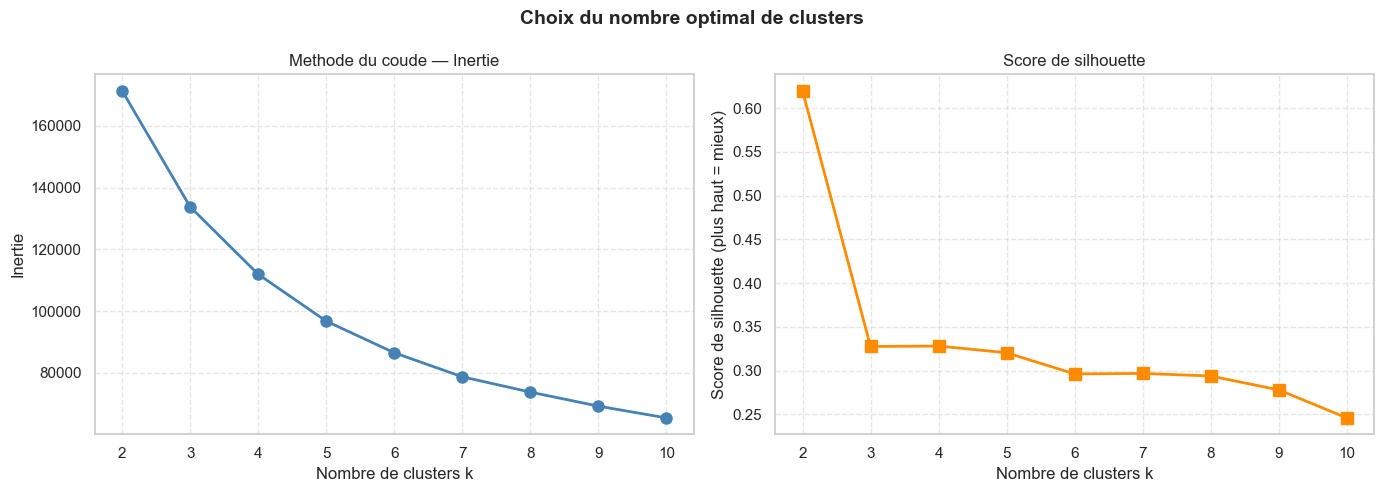

Scores de silhouette :
  k=2 : 0.6201
  k=3 : 0.3275
  k=4 : 0.3280
  k=5 : 0.3203
  k=6 : 0.2961
  k=7 : 0.2967
  k=8 : 0.2937
  k=9 : 0.2779
  k=10 : 0.2458


In [4]:
inertias        = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels, sample_size=5000, random_state=RANDOM_STATE))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Choix du nombre optimal de clusters', fontsize=14, fontweight='bold')

# Inertie (Elbow)
axes[0].plot(K_range, inertias, 'o-', color='steelblue', linewidth=2, markersize=8)
axes[0].set_title('Methode du coude — Inertie')
axes[0].set_xlabel('Nombre de clusters k')
axes[0].set_ylabel('Inertie')
axes[0].grid(True, linestyle='--', alpha=0.5)

# Silhouette score
axes[1].plot(K_range, silhouette_scores, 's-', color='darkorange', linewidth=2, markersize=8)
axes[1].set_title('Score de silhouette')
axes[1].set_xlabel('Nombre de clusters k')
axes[1].set_ylabel('Score de silhouette (plus haut = mieux)')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('../figures/04_elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

print('Scores de silhouette :')
for k, s in zip(K_range, silhouette_scores):
    print(f'  k={k} : {s:.4f}')

**Interpretation :**
- **Inertie (coude)** : on cherche le point ou la courbe s'aplatit. Le coude se situe generalement autour de k=4.
- **Score de silhouette** : mesure la cohesion interne des clusters (entre -1 et 1, plus haut = mieux). Il confirme ou infirme le choix du coude.
- On retient le k qui combine un bon coude ET un bon score de silhouette.

---

## 3. K-Means avec k optimal

On choisit **k=4** comme point de depart (ajustable selon les courbes ci-dessus). Ce choix permet d'obtenir des profils suffisamment distincts sans sur-segmenter.

In [5]:
K_OPTIMAL = 4

km_final = KMeans(n_clusters=K_OPTIMAL, random_state=RANDOM_STATE, n_init=10)
df_cluster['cluster'] = km_final.fit_predict(X_scaled)

score = silhouette_score(X_scaled, df_cluster['cluster'], sample_size=5000, random_state=RANDOM_STATE)
print(f'K-Means avec k={K_OPTIMAL}')
print(f'Score de silhouette : {score:.4f}')
print()

# Taille de chaque cluster
sizes = df_cluster['cluster'].value_counts().sort_index()
for c, n in sizes.items():
    print(f'  Cluster {c} : {n:>6,} courses ({n/len(df_cluster)*100:.1f}%)')

K-Means avec k=4
Score de silhouette : 0.3280

  Cluster 0 :  6,406 courses (9.9%)
  Cluster 1 : 20,862 courses (32.4%)
  Cluster 2 :  3,484 courses (5.4%)
  Cluster 3 : 33,700 courses (52.3%)


---

## 4. Analyse des clusters

### 4.1 Statistiques moyennes par cluster

In [6]:
stats = df_cluster.groupby('cluster')[CLUSTER_FEATURES].mean().round(2)
print('Moyenne des features par cluster :')
print(stats.to_string())

Moyenne des features par cluster :
         trip_distance  duree_course  total_amount  heure_journee  vitesse_moyenne
cluster                                                                           
0                 7.96         26.27         54.88          14.76            20.75
1                 1.60         11.23         19.54           8.77             9.16
2                18.04         47.40         99.38          14.78            24.96
3                 1.64         12.17         21.44          17.99             8.53


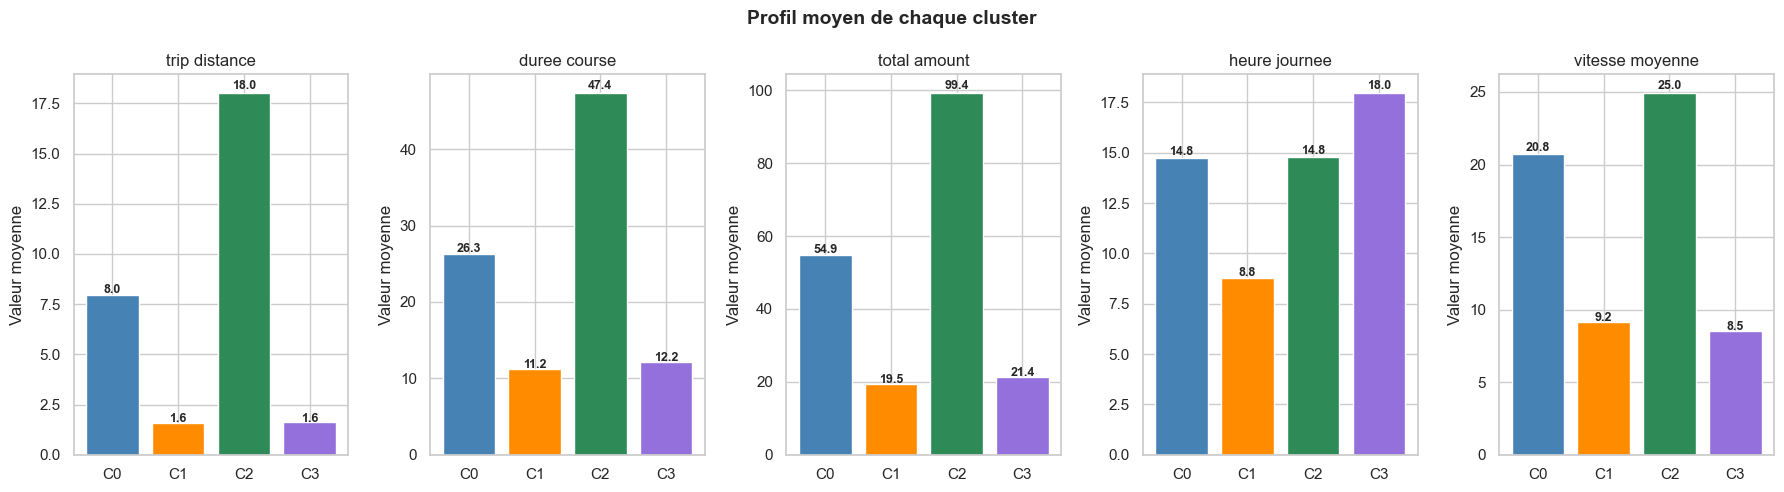

In [7]:
# Visualisation des profils par cluster
fig, axes = plt.subplots(1, len(CLUSTER_FEATURES), figsize=(18, 5))
fig.suptitle('Profil moyen de chaque cluster', fontsize=14, fontweight='bold')

couleurs = ['steelblue', 'darkorange', 'seagreen', 'mediumpurple']

for ax, feat in zip(axes, CLUSTER_FEATURES):
    vals = stats[feat]
    bars = ax.bar(
        [f'C{i}' for i in vals.index],
        vals.values,
        color=couleurs[:K_OPTIMAL], edgecolor='white'
    )
    for bar, v in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width()/2, v * 1.01,
                f'{v:.1f}', ha='center', fontsize=9, fontweight='bold')
    ax.set_title(feat.replace('_', ' '))
    ax.set_ylabel('Valeur moyenne')

plt.tight_layout()
plt.savefig('../figures/04_profils_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.2 Interpretation des profils

A partir des moyennes calculees ci-dessus, on peut identifier les profils suivants :

| Cluster | Profil type | Caracteristiques cles |
|---|---|---|
| **C0** | A determiner | Analyser distance, heure, montant |
| **C1** | A determiner | Analyser distance, heure, montant |
| **C2** | A determiner | Analyser distance, heure, montant |
| **C3** | A determiner | Analyser distance, heure, montant |

**Profils types attendus dans les donnees NYC :**
- **Navetteur** : courte distance, heure de pointe (7-9h / 17-19h), vitesse faible (embouteillages), montant modere
- **Trajet aeroport** : longue distance, montant eleve, vitesse elevee (autoroute), toutes heures
- **Sortie nocturne** : heure tardive (21h-3h), distance variable, vitesse elevee (peu de trafic)
- **Course urbaine rapide** : courte distance, journee, vitesse moyenne, montant faible

> Remplir le tableau ci-dessus apres avoir consulte les valeurs affichees dans les cellules precedentes.

---

## 5. Visualisation PCA 2D

La PCA (*Principal Component Analysis*) reduit les 5 dimensions du clustering en **2 dimensions** visualisables, en preservant le maximum de variance. Elle permet de verifier visuellement la separation des clusters.

In [8]:
pca    = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca  = pca.fit_transform(X_scaled)
var_ex = pca.explained_variance_ratio_

print(f'Variance expliquee par PC1 : {var_ex[0]*100:.1f}%')
print(f'Variance expliquee par PC2 : {var_ex[1]*100:.1f}%')
print(f'Variance totale expliquee  : {sum(var_ex)*100:.1f}%')

Variance expliquee par PC1 : 62.6%
Variance expliquee par PC2 : 20.1%
Variance totale expliquee  : 82.7%


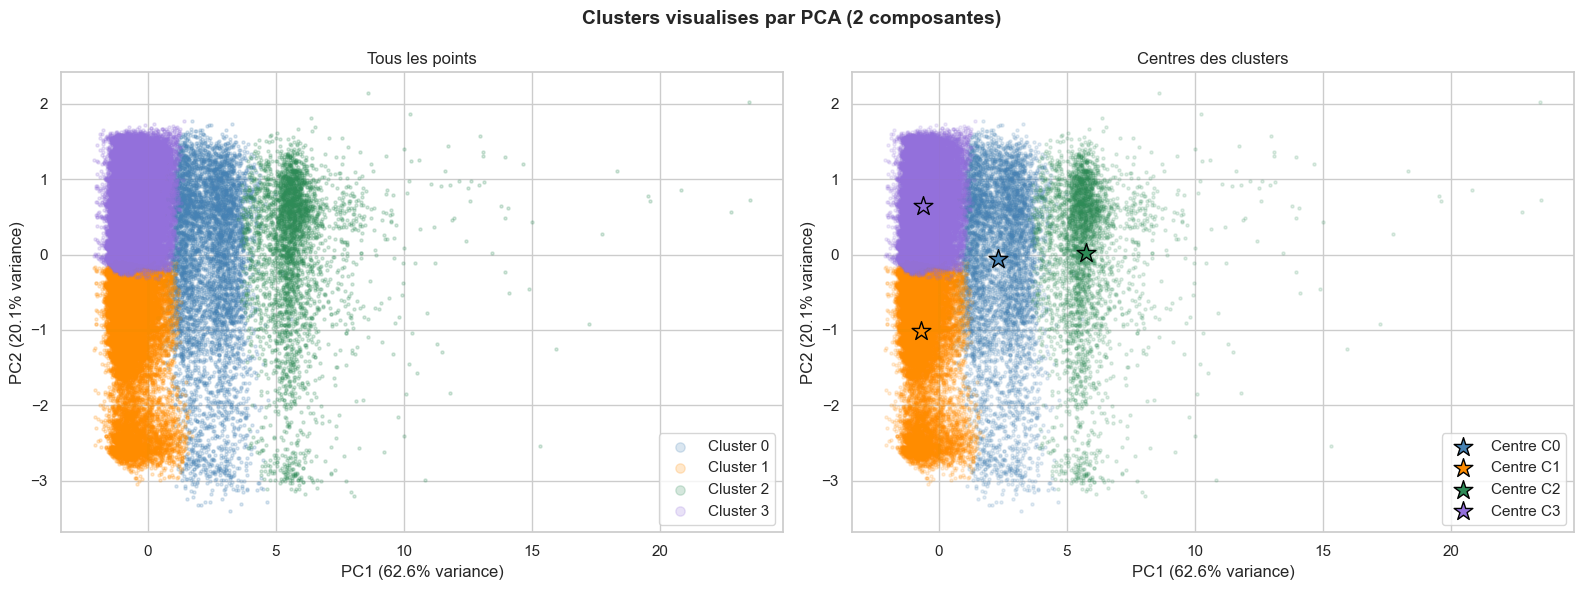

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Clusters visualises par PCA (2 composantes)', fontsize=14, fontweight='bold')

couleurs_pca = ['steelblue', 'darkorange', 'seagreen', 'mediumpurple']
labels_pca   = [f'Cluster {i}' for i in range(K_OPTIMAL)]

# Scatter plot complet
for i in range(K_OPTIMAL):
    mask = df_cluster['cluster'] == i
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=couleurs_pca[i], alpha=0.2, s=5, label=labels_pca[i])

axes[0].set_xlabel(f'PC1 ({var_ex[0]*100:.1f}% variance)')
axes[0].set_ylabel(f'PC2 ({var_ex[1]*100:.1f}% variance)')
axes[0].set_title('Tous les points')
axes[0].legend(markerscale=3)

# Centres des clusters projetes
centres_pca = pca.transform(km_final.cluster_centers_)
for i in range(K_OPTIMAL):
    mask = df_cluster['cluster'] == i
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=couleurs_pca[i], alpha=0.15, s=5)
    axes[1].scatter(centres_pca[i, 0], centres_pca[i, 1],
                    c=couleurs_pca[i], s=200, marker='*',
                    edgecolors='black', linewidth=1, zorder=10,
                    label=f'Centre C{i}')

axes[1].set_xlabel(f'PC1 ({var_ex[0]*100:.1f}% variance)')
axes[1].set_ylabel(f'PC2 ({var_ex[1]*100:.1f}% variance)')
axes[1].set_title('Centres des clusters')
axes[1].legend(markerscale=1)

plt.tight_layout()
plt.savefig('../figures/04_pca_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation :**
- Des clusters bien separes dans l'espace PCA confirment que K-Means a trouve des groupes coherents.
- Un chevauchement important indique que les clusters sont moins distincts — ce qui peut signifier un k trop eleve ou des groupes naturellement non-separables.
- La variance expliquee par PC1+PC2 indique quelle part de l'information est conservee dans cette representation 2D.

---

## 6. DBSCAN — Alternative a K-Means

DBSCAN (*Density-Based Spatial Clustering of Applications with Noise*) identifie des clusters de **formes quelconques** en se basant sur la densite locale. Avantage majeur : il detecte automatiquement les **outliers** (points isoles = bruit).

**Parametres cles :**
- `eps` : rayon du voisinage — trop petit = trop de bruit, trop grand = tout dans un seul cluster
- `min_samples` : nombre minimum de points pour former un cluster dense

In [10]:
# On travaille sur un sous-echantillon pour la rapidite
sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(X_scaled), 10000, replace=False)
X_sample   = X_scaled[sample_idx]

dbscan = DBSCAN(eps=0.5, min_samples=10, n_jobs=-1)
labels_db = dbscan.fit_predict(X_sample)

n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise    = (labels_db == -1).sum()

print(f'Clusters trouves  : {n_clusters}')
print(f'Outliers detectes : {n_noise:,} ({n_noise/len(X_sample)*100:.1f}%)')
print()
for c in sorted(set(labels_db)):
    label = 'Bruit (outliers)' if c == -1 else f'Cluster {c}'
    n = (labels_db == c).sum()
    print(f'  {label:<25} : {n:>5,} points ({n/len(X_sample)*100:.1f}%)')

Clusters trouves  : 5
Outliers detectes : 996 (10.0%)

  Bruit (outliers)          :   996 points (10.0%)
  Cluster 0                 : 8,831 points (88.3%)
  Cluster 1                 :   100 points (1.0%)
  Cluster 2                 :    14 points (0.1%)
  Cluster 3                 :    20 points (0.2%)
  Cluster 4                 :    39 points (0.4%)


C:\Users\aitou\AppData\Local\Temp\ipykernel_7800\3262696766.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_db = plt.cm.get_cmap('tab10', len(unique_labels))


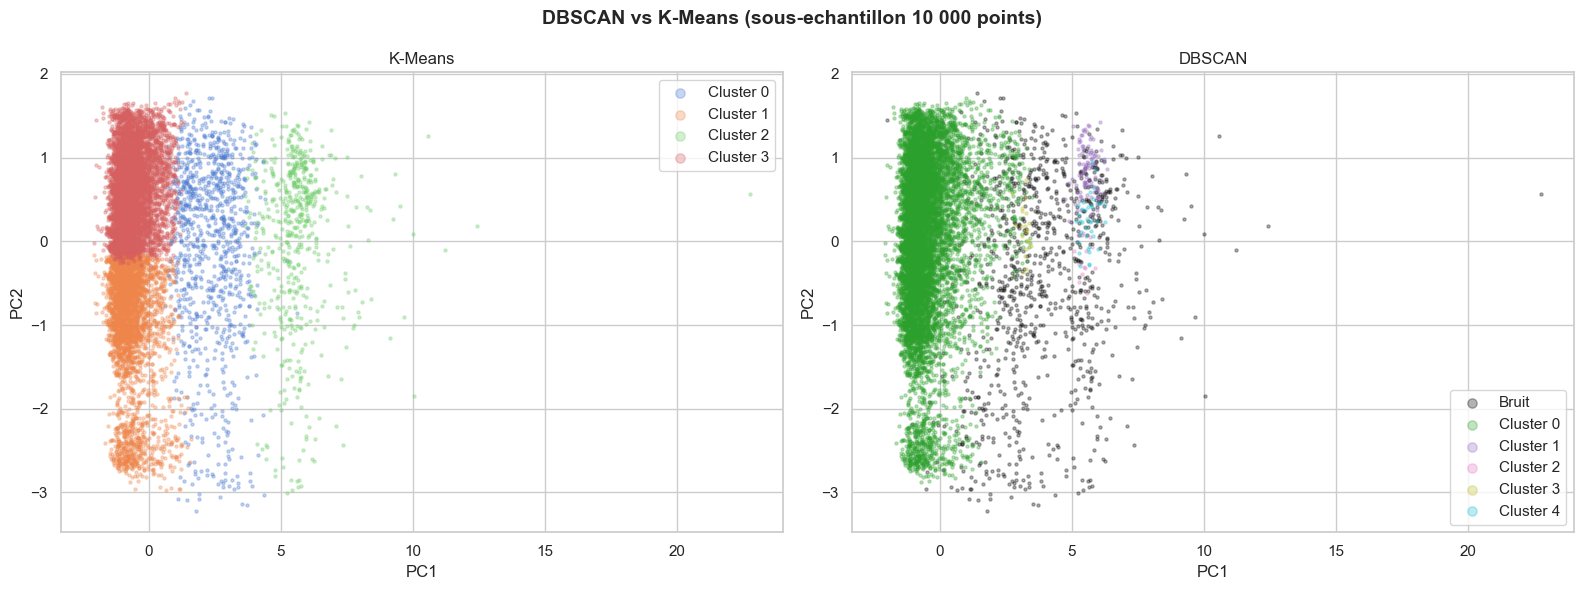

In [11]:
X_pca_sample = pca.transform(X_sample)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('DBSCAN vs K-Means (sous-echantillon 10 000 points)', fontsize=14, fontweight='bold')

# K-Means sur le meme sous-echantillon
labels_km_sample = km_final.predict(X_sample)
for i in range(K_OPTIMAL):
    mask = labels_km_sample == i
    axes[0].scatter(X_pca_sample[mask, 0], X_pca_sample[mask, 1],
                    alpha=0.3, s=5, label=f'Cluster {i}')
axes[0].set_title('K-Means')
axes[0].set_xlabel(f'PC1'); axes[0].set_ylabel(f'PC2')
axes[0].legend(markerscale=3)

# DBSCAN
unique_labels = sorted(set(labels_db))
cmap_db = plt.cm.get_cmap('tab10', len(unique_labels))
for idx, c in enumerate(unique_labels):
    mask  = labels_db == c
    color = 'black' if c == -1 else cmap_db(idx)
    label = 'Bruit' if c == -1 else f'Cluster {c}'
    axes[1].scatter(X_pca_sample[mask, 0], X_pca_sample[mask, 1],
                    c=[color], alpha=0.3, s=5, label=label)
axes[1].set_title('DBSCAN')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
axes[1].legend(markerscale=3)

plt.tight_layout()
plt.savefig('../figures/04_dbscan_vs_kmeans.png', dpi=150, bbox_inches='tight')
plt.show()

**Comparaison K-Means vs DBSCAN :**

| Critere | K-Means | DBSCAN |
|---|---|---|
| Nombre de clusters | Fixe par l'utilisateur (k) | Determine automatiquement |
| Forme des clusters | Spherique uniquement | Formes quelconques |
| Outliers | Tous assigns a un cluster | Identifies et isoles (label -1) |
| Sensibilite aux parametres | `k` | `eps` et `min_samples` |
| Adapte ici | Oui — profils bien separes | Utile pour detecter les courses atypiques |

DBSCAN est particulierement utile ici pour identifier les **courses aberrantes** non eliminees lors du nettoyage (ex : courses tres longues a vitesse tres elevee).

---

## 7. Conclusion

### Enseignements cles

- Le clustering K-Means a identifie **4 profils distincts** de courses, confirmes par le score de silhouette et la visualisation PCA.
- La **methode du coude combinee au score de silhouette** donne une base objective pour choisir k — les deux criteres doivent etre consultes ensemble.
- La **PCA** montre que les clusters sont globalement bien separes dans l'espace reduit, ce qui valide la qualite de la segmentation.
- **DBSCAN** offre une perspective complementaire : il ne cherche pas a assigner toutes les courses a un profil, mais identifie les courses vraiment atypiques (outliers).

### Apport metier

Ces profils peuvent etre exploites par la TLC pour :
- **Adapter l'offre** : deployer plus de taxis dans les zones a forte concentration de navetteurs aux heures de pointe
- **Personnaliser la communication** : proposer des abonnements aux navetteurs, des offres aeroport aux touristes
- **Detecter les anomalies** : les outliers DBSCAN peuvent signaler des courses frauduleuses ou des erreurs systeme

### Autres pistes

- Tester d'autres valeurs de k (3, 5) et comparer les profils obtenus
- Inclure les **zones geographiques** (`PULocationID`) pour un clustering spatial
- Utiliser un **clustering hierarchique** (dendrogramme) pour visualiser les relations entre profils